# Apriori - Desafio

In [15]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from mlxtend.frequent_patterns import apriori, association_rules

## Ler Dados

In [16]:
df_games = pd.read_csv("./dataset/game_sales.csv")
df_games.info()

<class 'pandas.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 3 columns):
 #   Column     Non-Null Count  Dtype
---  ------     --------------  -----
 0   Client ID  10000 non-null  str  
 1   Game ID    10000 non-null  str  
 2   Game Name  10000 non-null  str  
dtypes: str(3)
memory usage: 234.5 KB


In [17]:
df_games.rename(columns={
  'Client ID': 'client_id',
  'Game ID': 'game_id',
  "Game Name": 'game_name',
}, inplace=True)
df_games.info()

<class 'pandas.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 3 columns):
 #   Column     Non-Null Count  Dtype
---  ------     --------------  -----
 0   client_id  10000 non-null  str  
 1   game_id    10000 non-null  str  
 2   game_name  10000 non-null  str  
dtypes: str(3)
memory usage: 234.5 KB


## Análise Exploratória

### Ver se há registros duplicados
- Não há

In [78]:
len(df_games) == len(df_games.drop_duplicates())

True

### Valores Únicos

In [18]:
len(df_games['game_id'].unique())

33

In [19]:
len(df_games['game_name'].unique())

33

### Jogos mais vendidos

Text(0.5, 1.0, 'Jogos Mais Vendidos')

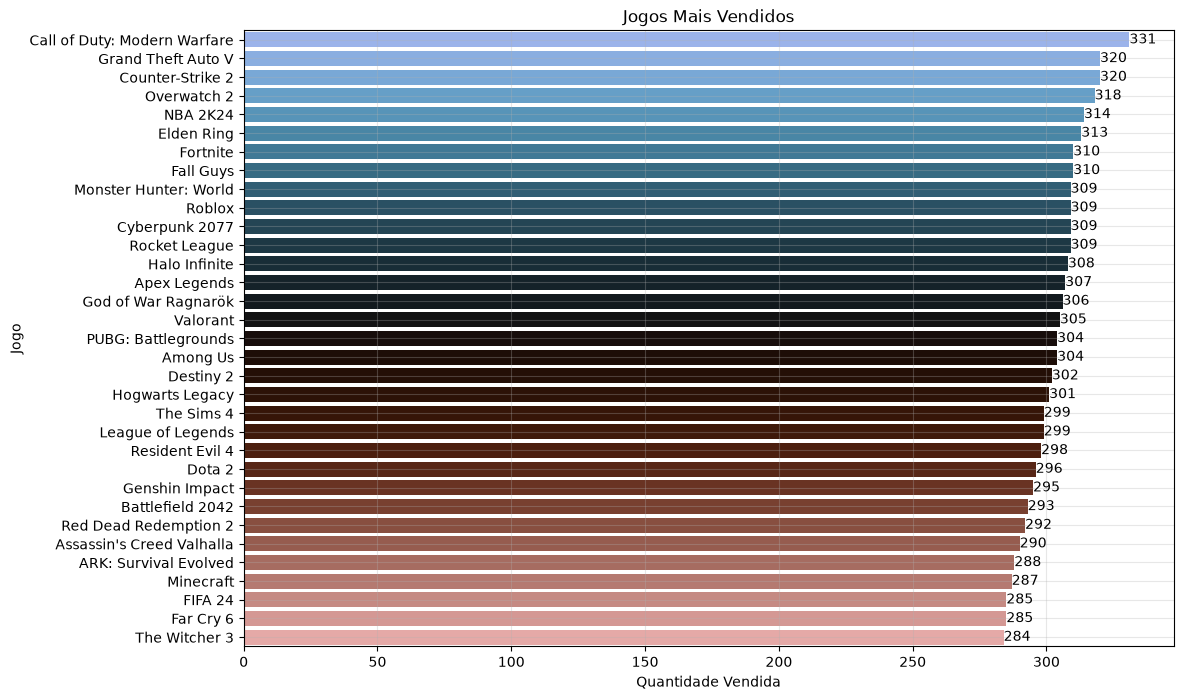

In [67]:
jogos_mais_vendidos = df_games.groupby('game_name')['client_id'].count().sort_values(ascending=False)
plt.figure(figsize=(12, 8))
ax = sns.barplot(
  y=jogos_mais_vendidos.index.values,
  x=jogos_mais_vendidos.values,
  hue=jogos_mais_vendidos.index.values,
  palette='berlin',
)
for container in ax.containers:
    ax.bar_label(container=container, fmt="%.d", label_type='edge', color='black') # type: ignore
plt.grid(visible=True, alpha=0.3)
plt.ylabel("Jogo")
plt.xlabel("Quantidade Vendida")
plt.title("Jogos Mais Vendidos")

### Porcentagem dos Jogos pelo Total de Clientes

Text(0.5, 1.0, 'Porcentagem de Jogos pelo Total de Clientes')

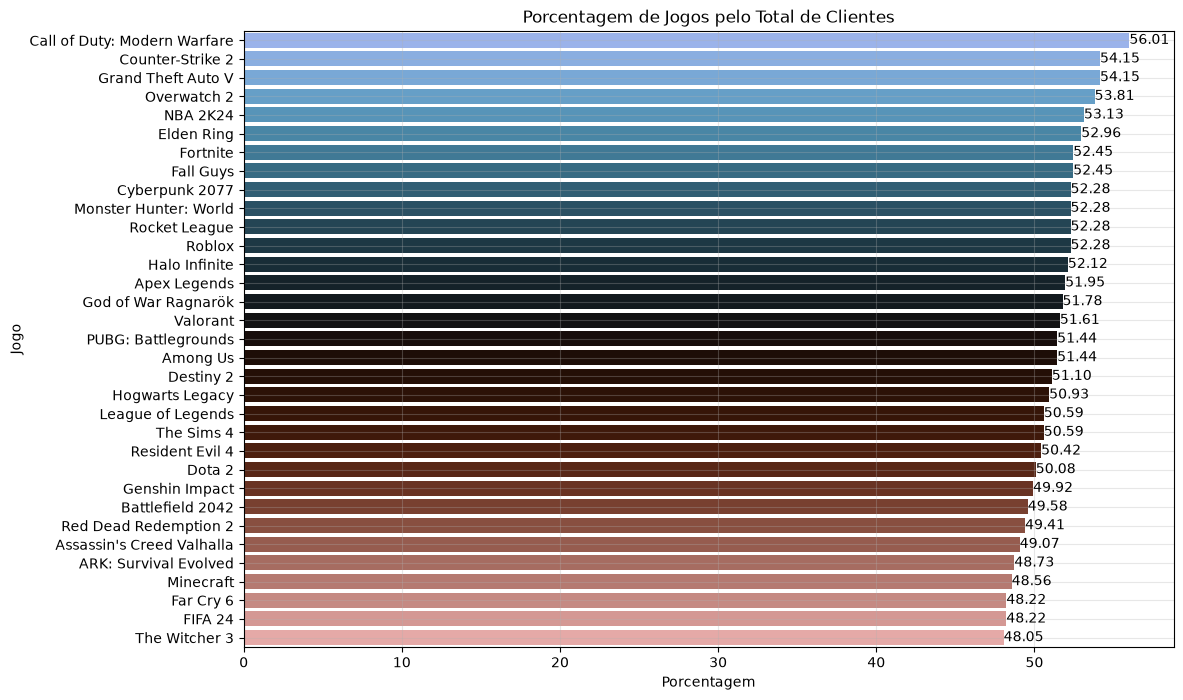

In [73]:
total_clientes = len(df_games['client_id'].unique())
porcentagem_jogos = df_games.value_counts('game_name') / total_clientes * 100
plt.figure(figsize=(12, 8))
ax = sns.barplot(
  y=porcentagem_jogos.index.values,
  x=porcentagem_jogos.values,
  hue=porcentagem_jogos.index.values,
  palette='berlin',
)
for container in ax.containers:
    ax.bar_label(container=container, fmt="%.2f", label_type='edge', color='black') # type: ignore
plt.grid(visible=True, alpha=0.3)
plt.ylabel("Jogo")
plt.xlabel("Porcentagem")
plt.title("Porcentagem de Jogos pelo Total de Clientes")

### Pivot Table
- Seleciona `game_name` para ser as colunas.
- Seleciona `client_id` para ser os registros.
- Se o cliente tem o jogo x, marca True. Senão, marca False.
- Remove o índice `game_name`.
- remove a coluna `client_id`.

In [ ]:
pivot_table = df_games.pivot_table(
  columns='game_name',
  aggfunc='count',
  index='client_id',
  values='game_name'
).map(
  lambda x: True if x>0 else False
).rename_axis(
  None,
  axis=1
).reset_index().drop(columns=['client_id'])
pivot_table

game_name,ARK: Survival Evolved,Among Us,Apex Legends,Assassin's Creed Valhalla,Battlefield 2042,Call of Duty: Modern Warfare,Counter-Strike 2,Cyberpunk 2077,Destiny 2,Dota 2,...,NBA 2K24,Overwatch 2,PUBG: Battlegrounds,Red Dead Redemption 2,Resident Evil 4,Roblox,Rocket League,The Sims 4,The Witcher 3,Valorant
0,True,True,False,True,False,True,True,True,True,False,...,True,True,True,True,True,True,True,True,True,True
1,False,True,True,True,True,True,False,False,False,False,...,False,True,False,False,True,False,True,False,False,True
2,True,True,True,False,False,True,True,True,True,False,...,True,False,True,False,True,True,True,True,False,True
3,True,False,True,False,True,True,True,False,False,True,...,True,False,False,True,True,True,True,False,True,False
4,True,False,True,False,True,True,False,True,True,True,...,False,True,False,False,False,True,True,True,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
586,False,True,True,False,False,True,False,False,False,False,...,True,False,True,True,True,False,True,False,True,True
587,True,True,True,False,True,True,True,True,True,True,...,True,True,True,True,True,True,True,True,True,True
588,False,True,True,True,False,True,True,True,True,True,...,True,True,True,False,True,True,False,False,False,True
589,True,True,False,False,True,True,True,False,False,False,...,False,False,False,False,True,True,False,True,False,False


### Correlação de Pearson

Text(0.5, 1.0, 'Correlação de Pearson')

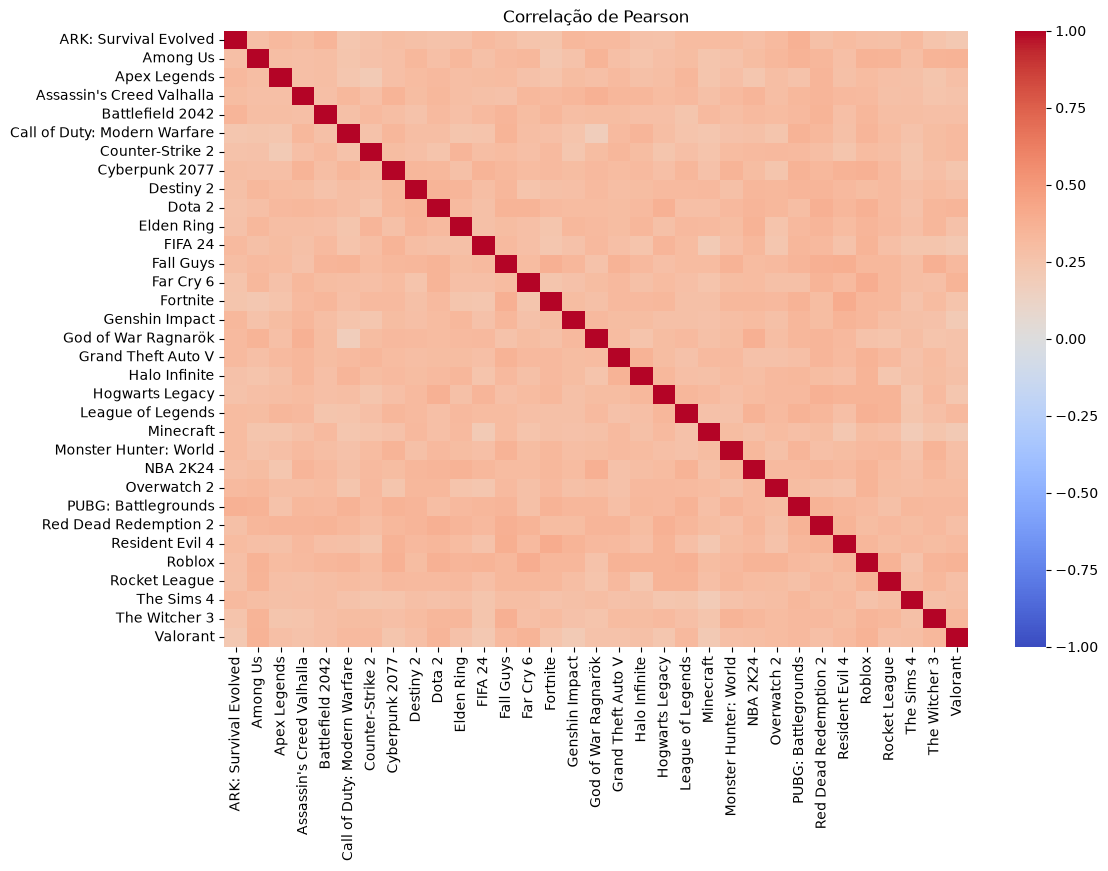

In [115]:
pearson_corr = pivot_table.corr()
plt.figure(figsize=(12,8))
sns.heatmap(
  pearson_corr,
  vmin=-1,
  vmax=1,
  annot=False,
  cmap='coolwarm',
)
plt.ylabel("")
plt.xlabel("")
plt.title("Correlação de Pearson")

## Algoritmo Apriori
- Como os jogos tem um suporte de aproximadamente 50%, usei que o esperado de proporção para obter dois jogos é 0.5 x 0.5, sendo 0.25.
- Como isso daria muitos casos ainda, subi um pouco o suporte mínimo para 30%.

In [160]:
itemsets_frequentes = apriori(pivot_table, min_support=0.3, verbose=1, use_colnames=True)
itemsets_frequentes['tamanho'] = itemsets_frequentes['itemsets'].apply(lambda x: len(x))
itemsets_frequentes.sort_values(by=['tamanho', 'support'], ascending=False)

Processing 15666 combinations | Sampling itemset size 3


,support,itemsets,tamanho
553,0.301184,"frozenset({Call of Duty: Modern Warfare, Grand...",3
186,0.382403,"frozenset({Call of Duty: Modern Warfare, Fall ...",2
191,0.382403,"frozenset({Call of Duty: Modern Warfare, Grand...",2
202,0.379019,"frozenset({Call of Duty: Modern Warfare, Roblox})",2
181,0.377327,"frozenset({Call of Duty: Modern Warfare, Cyber...",2
...,...,...,...
0,0.487310,frozenset({ARK: Survival Evolved}),1
21,0.485618,frozenset({Minecraft}),1
11,0.482234,frozenset({FIFA 24}),1
13,0.482234,frozenset({Far Cry 6}),1


### Regras de Associação
- Utilizando confiança = 0.8
- Utilizando confiança = 0.75
- Utilizando Confiança 0.72

In [154]:
regras_associacao = association_rules(itemsets_frequentes, metric='confidence', min_threshold=0.8)
regras_associacao

,antecedents,consequents,antecedent support,consequent support,support,confidence,lift,representativity,leverage,conviction,zhangs_metric,jaccard,certainty,kulczynski
0,"frozenset({Grand Theft Auto V, Fall Guys})",frozenset({Call of Duty: Modern Warfare}),0.373942,0.560068,0.301184,0.80543,1.438094,1.0,0.091751,2.261047,0.486593,0.475936,0.557727,0.671597


In [155]:
regras_associacao = association_rules(itemsets_frequentes, metric='confidence', min_threshold=0.75)
regras_associacao

,antecedents,consequents,antecedent support,consequent support,support,confidence,lift,representativity,leverage,conviction,zhangs_metric,jaccard,certainty,kulczynski
0,"frozenset({Call of Duty: Modern Warfare, Grand...",frozenset({Fall Guys}),0.382403,0.524535,0.301184,0.787611,1.501542,1.0,0.100601,2.238649,0.540834,0.497207,0.553302,0.680902
1,"frozenset({Call of Duty: Modern Warfare, Fall ...",frozenset({Grand Theft Auto V}),0.382403,0.541455,0.301184,0.787611,1.454618,1.0,0.094131,2.158982,0.506049,0.483696,0.536819,0.671930
2,"frozenset({Grand Theft Auto V, Fall Guys})",frozenset({Call of Duty: Modern Warfare}),0.373942,0.560068,0.301184,0.805430,1.438094,1.0,0.091751,2.261047,0.486593,0.475936,0.557727,0.671597


In [158]:
regras_associacao = association_rules(itemsets_frequentes, metric='confidence', min_threshold=0.72)
regras_associacao

,antecedents,consequents,antecedent support,consequent support,support,confidence,lift,representativity,leverage,conviction,zhangs_metric,jaccard,certainty,kulczynski
0,frozenset({Assassin's Creed Valhalla}),frozenset({Call of Duty: Modern Warfare}),0.490694,0.560068,0.357022,0.727586,1.299104,1.0,0.082200,1.614941,0.452063,0.514634,0.380782,0.682524
1,frozenset({Cyberpunk 2077}),frozenset({Call of Duty: Modern Warfare}),0.522843,0.560068,0.377327,0.721683,1.288564,1.0,0.084499,1.580687,0.469325,0.534772,0.367364,0.697699
2,frozenset({Fall Guys}),frozenset({Call of Duty: Modern Warfare}),0.524535,0.560068,0.382403,0.729032,1.301686,1.0,0.088628,1.623560,0.487450,0.544578,0.384069,0.705906
3,frozenset({Halo Infinite}),frozenset({Call of Duty: Modern Warfare}),0.521151,0.560068,0.377327,0.724026,1.292747,1.0,0.085447,1.594108,0.472912,0.536058,0.372690,0.698871
4,frozenset({PUBG: Battlegrounds}),frozenset({Call of Duty: Modern Warfare}),0.514382,0.560068,0.377327,0.733553,1.309757,1.0,0.089238,1.651104,0.487008,0.541262,0.394345,0.703634
5,frozenset({Red Dead Redemption 2}),frozenset({Call of Duty: Modern Warfare}),0.494078,0.560068,0.358714,0.726027,1.296321,1.0,0.081997,1.605753,0.451821,0.515815,0.377239,0.683255
6,frozenset({Roblox}),frozenset({Call of Duty: Modern Warfare}),0.522843,0.560068,0.379019,0.724919,1.294342,1.0,0.086191,1.599283,0.476586,0.538462,0.374720,0.700828
7,frozenset({The Witcher 3}),frozenset({Fall Guys}),0.480541,0.524535,0.346870,0.721831,1.376136,1.0,0.094809,1.709268,0.526178,0.526992,0.414954,0.691561
8,frozenset({Far Cry 6}),frozenset({Roblox}),0.482234,0.522843,0.350254,0.726316,1.389167,1.0,0.098122,1.743460,0.541063,0.534884,0.426428,0.698109
9,frozenset({Resident Evil 4}),frozenset({Fortnite}),0.504230,0.524535,0.365482,0.724832,1.381858,1.0,0.100996,1.727911,0.557388,0.551020,0.421266,0.710803
